# RMSNorm: Verifying Correctness and Performance



Now that you have learned how to derive backpropagation for RMSNorm and the memory-saving tricks, the implementation itself is relatively straightforward. Therefore, we will focus on testing and use the existing implementation from Liger Kernel.

### Ensure you are using GPU by running `nvidia-smi`

In [ ]:
!nvidia-smi

Tue Aug 20 18:24:27 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   60C    P8              12W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

### Install liger-kernel for RMSNorm implementation

In [ ]:
!pip install liger-kernel

### Why Testing?

Assuming we have a working version of RMSNorm, we cannot confidently deploy it to production without verifying the following:

1. **Correctness:** Ensure that the kernel is as precise as the original implementation. Any deviation could impact model convergence or even cause critical errors.

2. **Performance:** Confirm that the kernel is more time- and memory-efficient than the original version. Without these improvements, re-implementing in Triton would not be justified.

## Correctness Test

Prepare a pure PyTorch implementation, such as the one provided by [HuggingFace](https://sourcegraph.com/github.com/huggingface/transformers/-/blob/src/transformers/models/llama/modeling_llama.py?L111).

We want to test the implementation with different input shapes and data types. In addition to regular shapes like powers of 2, it's important to test irregular shapes to ensure proper handling of edge cases.

Setting the tolerance can be tricky. Generally, for `fp32`, use `atol = 1e-7` and `rtol = 1e-5`. For `bf16`, use `atol = 1e-3` and `rtol = 1e-2`. However, in practice, the tolerance may need to be further relaxed in some cases, even when the kernel is exact.

Later, we will discuss another testing method to validate that the kernel does not negatively impact end-to-end convergence.

In [ ]:
import torch
import torch.nn as nn


# Copy from HuggingFace

class LlamaRMSNorm(nn.Module):
    def __init__(self, hidden_size, eps=1e-6):
        """
        LlamaRMSNorm is equivalent to T5LayerNorm
        """
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))
        self.variance_epsilon = eps

    def forward(self, hidden_states):
        input_dtype = hidden_states.dtype
        hidden_states = hidden_states.to(torch.float32)
        variance = hidden_states.pow(2).mean(-1, keepdim=True)
        hidden_states = hidden_states * torch.rsqrt(variance + self.variance_epsilon)
        return self.weight * hidden_states.to(input_dtype)


In [ ]:
import torch
from liger_kernel.transformers.rms_norm import LigerRMSNorm


input_data = [
    (4, 16, 32, torch.float32, 1e-6, 1e-4),
    (8, 32, 64, torch.float32, 1e-6, 1e-4),
    (16, 64, 128, torch.float32, 1e-6, 1e-4),
    (3, 9, 13, torch.float32, 1e-6, 1e-4),
    # T4 GPU doesn't support bf16 :(
    # (16, 64, 128, torch.bfloat32, 1e-3, 1e-2),
]

for bs, sl, hd, dtype, atol, rtol in input_data:
    # h
    _tensor = torch.randn(bs, sl, hd, device="cuda", dtype=dtype)

    h1 = _tensor.clone().requires_grad_(True)
    h2 = _tensor.clone().requires_grad_(True)

    # do
    do = torch.randn(bs, sl, hd, device="cuda", dtype=dtype)

    # llama
    llama_rms = LlamaRMSNorm(hidden_size=hd).to("cuda").to(dtype)
    llama_o = llama_rms(h1)
    llama_o.backward(do.clone(), retain_graph=True)

    # triton
    triton_rms = LigerRMSNorm(hidden_size=hd).to("cuda").to(dtype)
    triton_o = triton_rms(h2)
    triton_o.backward(do.clone(), retain_graph=True)

    assert torch.allclose(llama_o, triton_o, atol=atol, rtol=rtol) is True

    # print(h1.grad, h2.grad)
    assert torch.allclose(h1.grad, h2.grad, atol=atol, rtol=rtol) is True

### Performance Test

There are two dimensions we want to test: Speed and Memory. But what input shape should I use to test? You can use the actual input shape from your training for testing. For example, when fine-tuning the LLaMA 3-8B model, we usually use a batch size of 4 and a hidden size of 2048. We make the sequence length a variant.


This way, the test results will reflect the actual gains we can expect to see in production training.

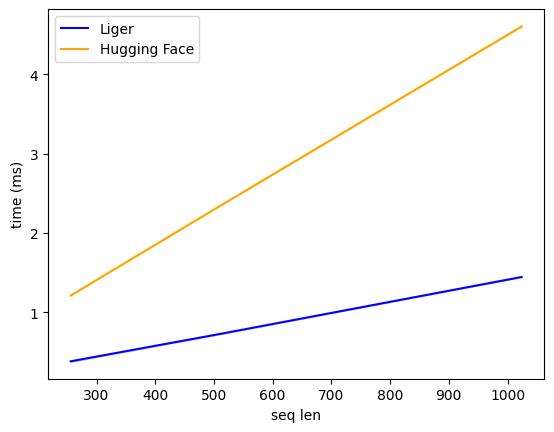

rmsnorm-full-speed-benchmark:
   seq_len     Liger  Hugging Face
0    256.0  0.382000      1.211072
1    512.0  0.729088      2.348544
2   1024.0  1.444832      4.603904


In [ ]:
import os

import torch
import torch.nn as nn
import triton


@triton.testing.perf_report(
    [
        triton.testing.Benchmark(
            x_names=["seq_len"],
            x_vals=[2**i for i in range(8, 11)], # 256, 512, 1024
            xlabel="seq len",
            line_arg="provider",
            line_vals=["liger", "huggingface"],
            line_names=["Liger", "Hugging Face"],
            styles=[("blue", "solid"), ("orange", "solid")],
            ylabel="time (ms)",
            plot_name="rmsnorm-full-speed-benchmark",
            args={"batch_size": 4, "hidden_size": 2048, "dtype": torch.float32, "mode": "full"},
        ),
    ]
)
def bench_speed_rms_norm(batch_size, seq_len, hidden_size, dtype, provider, mode, eps=1e-5, device="cuda"):
    x_shape = (batch_size, seq_len, hidden_size)

    triton_rms = LigerRMSNorm(hidden_size=hidden_size).to("cuda")
    llama_rms = LlamaRMSNorm(hidden_size=hidden_size).to("cuda")

    x = torch.randn(x_shape, dtype=dtype, device="cuda")
    dy = torch.randn_like(x)
    x.requires_grad_(True)

    x = x.view(batch_size * seq_len, hidden_size)
    dy = dy.view(batch_size * seq_len, hidden_size)

    quantiles = [0.5, 0.2, 0.8]


    def full():
        if provider == "liger":
            y = triton_rms(x)
        elif provider == "huggingface":
            y = llama_rms(x)

        y.backward(dy, retain_graph=True)

    ms, min_ms, max_ms = triton.testing.do_bench(
        full, quantiles=quantiles, grad_to_none=[x], rep=500
    )

    return ms, max_ms, min_ms


bench_speed_rms_norm.run(show_plots=True, print_data=True)


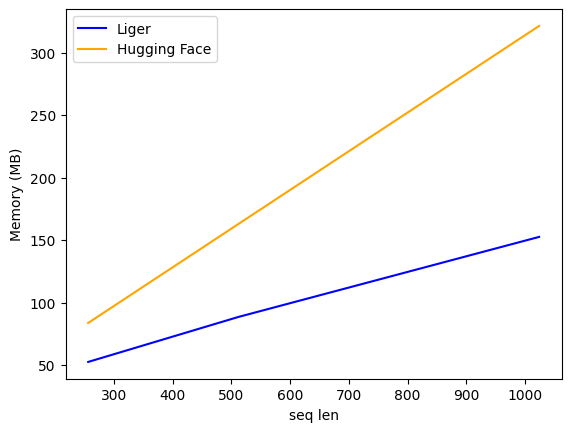

rmsnorm-full-memory-benchmark:
   seq_len       Liger  Hugging Face
0    256.0   52.544629     83.737109
1    512.0   88.548535    162.941016
2   1024.0  152.556348    321.348828


In [ ]:
def test_memory(func, _iter):
    total_mem = []

    for _ in range(_iter):
        torch.cuda.memory.reset_peak_memory_stats()
        func()
        mem = torch.cuda.max_memory_allocated() / (2**20)
        total_mem.append(mem)

    return sum(total_mem) / len(total_mem)

@triton.testing.perf_report(
    [
        triton.testing.Benchmark(
            x_names=["seq_len"],
            x_vals=[2**i for i in range(8, 11)], # 256, 512, 1024
            xlabel="seq len",
            line_arg="provider",
            line_vals=["liger", "huggingface"],
            line_names=["Liger", "Hugging Face"],
            styles=[("blue", "solid"), ("orange", "solid")],
            ylabel="Memory (MB)",
            plot_name="rmsnorm-full-memory-benchmark",
            args={"batch_size": 4, "hidden_size": 2048, "dtype": torch.float32, "mode": "full"},
        ),
    ]
)
def bench_memory_rms_norm(batch_size, seq_len, hidden_size, dtype, provider, mode, eps=1e-5, device="cuda"):
    x_shape = (batch_size, seq_len, hidden_size)

    triton_rms = LigerRMSNorm(hidden_size=hidden_size).to("cuda")
    llama_rms = LlamaRMSNorm(hidden_size=hidden_size).to("cuda")

    x = torch.randn(x_shape, dtype=dtype, device="cuda")
    dy = torch.randn_like(x)
    x.requires_grad_(True)

    x = x.view(batch_size * seq_len, hidden_size)
    dy = dy.view(batch_size * seq_len, hidden_size)

    quantiles = [0.5, 0.2, 0.8]


    def full():
        if provider == "liger":
            y = triton_rms(x)
        elif provider == "huggingface":
            y = llama_rms(x)

        y.backward(dy, retain_graph=True)

    mem = test_memory(full, 10)

    return mem

bench_memory_rms_norm.run(show_plots=True, print_data=True)

### Final Notes

We can clearly see that the Triton implementation is superior in both speed and memory, and we have also verified its exactness! Due to the GPU constraints of Google Colab, we performed only partial testing. In the actual testing of Liger-Kernel, we also validated bf16 with much larger input sizes. Please refer to [https://github.com/linkedin/Liger-Kernel](https://github.com/linkedin/Liger-Kernel) for the full-fledged version.